In [109]:
# The RFSoC will be receiving ~19 bit samples per I/Q channel, then muxing, then sending to PS/PL memory.
#       From there, depending on the path, it will need to be either sent over QSFP, or analyzed to get
#       the beam current in the specific helicity window. Since the ~19 bit samples are packaged into
#       24 bit words to get 3 64 bit words, the total data rate is 8*24*15.625 Mbps = 375 MB/s. Before
#       we actually get data in this format, it is good to try to simulate such data to see if the 
#       various software downmixers can keep up with this rate. 

In [ ]:
import numpy as np
from numpy.fft import fft, fftfreq, rfftfreq
import matplotlib.pyplot as plt

In [111]:
data_size_MB = 400
num_chs = 8
bits_per_single_sample = 24
sig_bits = 19
sample_rate = 15.625e6
if_freq = 1e6
noise = 0.003
helicity_freq = 1.92e3
rng_seed = 137

In [112]:
amplitude = 2**(sig_bits - 1)
num_samples = int(data_size_MB * 1e6 * 8 / num_chs / bits_per_single_sample)
num_samples_per_helicity = int(sample_rate/helicity_freq)
samp_freq_noise = np.sqrt(num_samples_per_helicity) * noise *amplitude / np.sqrt(2) # sqrt(2) because this is noise in I or Q channel
time_domain = np.arange(num_samples)/sample_rate
rng = np.random.default_rng(rng_seed)

In [ ]:
def dirichlet_kernel(freqs, M, f0):
    return 1./M * np.sin(np.pi*M*freqs/f0)/np.sin(np.pi*freqs/f0)

def find_std_per_bin(window_std, num_samp_pad, freq, samp_per_stable):

    freq_domain = rfftfreq(num_samp_pad, 1/freq)
    transfer_function = dirichlet_kernel(freq_domain[1:], samp_per_stable, freq)
    transfer_sum_weighted = np.sum(transfer_function**2)
    transfer_sum_weighted *= 2.
    freq_std = num_samp_pad/np.sqrt(2*transfer_sum_weighted)*window_std

    return freq_std

In [161]:
data = np.empty((num_chs, num_samples), dtype=np.int32)

In [162]:
phases = rng.uniform(-np.pi, np.pi, num_chs//2)
noise = rng.normal(0, samp_freq_noise, (num_chs//2, num_samples))

In [163]:
i_mask = np.arange(num_chs)%2 == 0
args = 2*np.pi*if_freq*np.repeat(time_domain[np.newaxis,:], num_chs//2, axis=0) + np.repeat(phases[:,np.newaxis], num_samples, axis=1)
data[i_mask] = amplitude/np.sqrt(2) * np.sin(args) + noise
roll_amount = np.round(0.25 * sample_rate/if_freq)
# print(roll_amount)
data[~i_mask] = np.roll(np.copy(data[i_mask]), roll_amount)

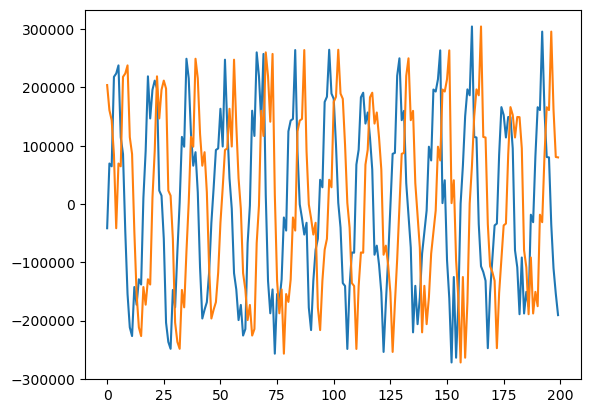

In [164]:
fig, ax = plt.subplots()
ax.plot(data[0,:200])
ax.plot(data[1,:200])
plt.show()

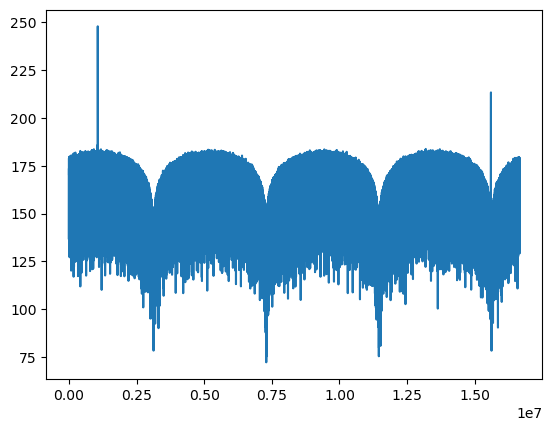

In [165]:
freq_data = fft(data[0] + 1j*data[1])
fig, ax = plt.subplots()
ax.plot(20*np.log10(np.abs(freq_data)))
plt.show()